# 1. Fully connected neural networks

First, we import the libraries we need to load the data, prepare it, and build the neural network.

In [20]:
import numpy as np
import pandas as pd

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical

import matplotlib.pyplot as plt

We load the data and name the columns.

In [21]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

df = pd.read_csv(url, header=None, names=columns)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


We split the data into inputs (x) and outputs (y).

In [22]:
x = df.iloc[:, 0:4].values
y = df.iloc[:, 4].values

Since the model can't read words, we change them into numbers.

In [23]:
class_mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

y = np.array([class_mapping[label] for label in y])

We apply one-hot encoding to turn the labels into vectors of numbers.

In [24]:
y = to_categorical(y, num_classes=3)

We shuffle the dataset so the model learns from random data instead of a fixed order.

In [25]:
indices = np.arange(x.shape[0])
np.random.shuffle(indices)

x = x[indices]
y = y[indices]

print("Feature shape:", x.shape)
print("Label shape:", y.shape)

Feature shape: (150, 4)
Label shape: (150, 3)


We create a simple neural network with one hidden layer and one output layer that uses softmax.

In [31]:
model = Sequential([
    Dense(8, activation="relu", input_shape=(4, )),
    Dense(3, activation="softmax")
])

We set up the model using the Adam optimizer, categorical crossentropy loss, and accuracy as the metric.

In [32]:
optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

We train the model for 50 epochs, with a batch size of 8, and use 20% of the data for validation.

In [28]:
history = model.fit(
    x,
    y,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3333 - loss: 3.9383 - val_accuracy: 0.7333 - val_loss: 0.9358
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3917 - loss: 0.9965 - val_accuracy: 0.2667 - val_loss: 0.9958
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6250 - loss: 0.7583 - val_accuracy: 0.6333 - val_loss: 0.6238
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6917 - loss: 0.6216 - val_accuracy: 0.7000 - val_loss: 0.5301
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7583 - loss: 0.5458 - val_accuracy: 0.8667 - val_loss: 0.4647
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8083 - loss: 0.5016 - val_accuracy: 0.6333 - val_loss: 0.4591
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7750 - loss: 0.4744 - val_accuracy: 0.7000 - val_loss: 0.4195
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9083 - loss: 0.4232 - val_accuracy: 0.9667 - val_loss

We plot the training and validation accuracy to see how the model is learning.

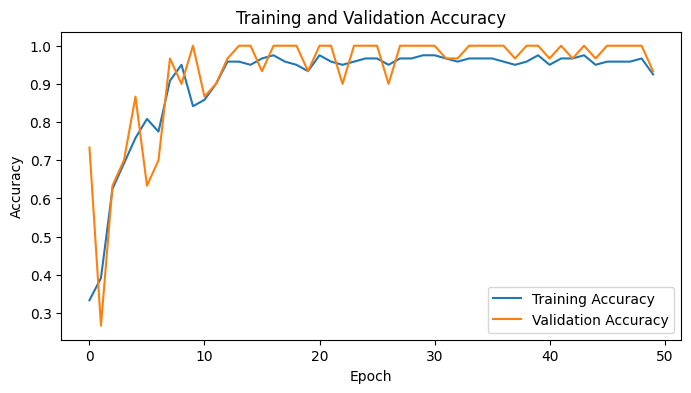

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()